In [9]:
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime
import cftime

from scipy.stats import pearsonr
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error
from scipy.stats import ttest_ind

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec
from gpi_reader import(
     GPIReader
)

In [10]:
class GPIMetricEvaluator:
    def __init__(self, data_dir, exp_dict, syear, eyear, varname="GPI", ref_label="ERA5"):
        self.data_dir = data_dir
        self.exp_dict = exp_dict
        self.syear = syear
        self.eyear = eyear
        self.varname = varname
        self.ref_label = ref_label
        self.gpi_data = {}
        self.annual_means = {}
        self.monthly_clim = {}
        self.genesis_dict = None

    def normalize_longitude(self,da):
        if da.lon.max() > 180:
            da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
            da = da.sortby('lon')
        return da

    def normalize_time(self, da, exp):
        """Normalize time to the first day of the month.
        For model experiments, shift back 15 days if needed.
        Handles both numpy.datetime64 and cftime.datetime types.
        Skips normalization if already aligned to YYYY-MM-01.
        """
        da = da.copy()
        time_vals = da['time'].values

        # Step 1: Shift mid-month model time to early month
        if exp != "ERA5":
            if isinstance(time_vals[0], cftime.datetime):
                time_vals = [t - datetime.timedelta(days=15) for t in time_vals]
            else:
                time_vals = time_vals - np.timedelta64(15, 'D')

        # Step 2: Check if already normalized (day == 1)
        if isinstance(time_vals[0], cftime.datetime):
            if all(t.day == 1 for t in time_vals):
                da['time'] = time_vals  # still assign in case shift was applied
                return da
            normalized = [type(t)(t.year, t.month, 1) for t in time_vals]
        else:
            dt_check = pd.to_datetime(time_vals)
            if (dt_check.day == 1).all():
                da['time'] = dt_check
                return da
            normalized = pd.to_datetime(dt_check.to_period("M").astype(str))

        da['time'] = normalized
        return da

    def load_all_data(self):
        self.load_variable_data(self.varname)

    def load_variable_data(self, varname):
        self.gpi_data[varname] = {}
        for exp in self.exp_dict:
            reader = GPIReader(self.data_dir, exp, self.syear, self.eyear, gpi_vars=[varname])
            reader.load_data()
            self.gpi_data[varname][exp] = reader.get_data(varname)

    def set_genesis_data(self, genesis_dict):
        self.genesis_dict = genesis_dict

    def compute_annual_mean(self):
        self.compute_annual_mean_var(self.varname)

    def compute_annual_mean_var(self, varname):
        self.annual_means[varname] = {
            exp: da.mean("time") for exp, da in self.gpi_data[varname].items()
        }
        
    def compute_hemisphere_custom_seasonal_mean(self, varname, nh_months=[8, 9, 10], sh_months=[1, 2, 3]):
        """Compute hemisphere-specific seasonal means:
        - Northern Hemisphere (lat ≥ 0): using `nh_months`
        - Southern Hemisphere (lat < 0): using `sh_months`
        """
        seasonal_means = {}

        for exp, da in self.gpi_data[varname].items():
            da = self.normalize_longitude(da)
            da = self.normalize_time(da,exp)
            da = da.load()

            months = da["time.month"]

            # Northern Hemisphere: NH months
            nh_mask = da["lat"] >= 0
            nh_month_mask = months.isin(nh_months)
            nh_data = da.sel(lat=nh_mask).where(nh_month_mask, drop=True).mean("time")

            # Southern Hemisphere: SH months
            sh_mask = da["lat"] < 0
            sh_month_mask = months.isin(sh_months)
            sh_data = da.sel(lat=sh_mask).where(sh_month_mask, drop=True).mean("time")

            # Combine NH and SH
            combined = xr.concat([nh_data, sh_data], dim="lat").sortby("lat")
            seasonal_means[exp] = combined

        self.annual_means[varname] = seasonal_means


    def plot_means_and_biases_combined_var(
        self, varname,
        ncols=2, nrows=3,
        figsize=(11, 9), fontz=10,
        wspace=0.15, hspace=0.15,
        clevels_mean=None, clevels_bias=None,
        save_path=None
    ):
        if varname not in self.annual_means:
            raise ValueError(f"Annual mean not computed for {varname}. Run compute_annual_mean_var('{varname}') first.")

        n = len(self.annual_means[varname])
        total_panels = nrows * ncols
        if n > total_panels:
            raise ValueError(f"Not enough panels ({total_panels}) for {n} experiments. Increase rows/cols.")

        fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                                 subplot_kw={"projection": ccrs.PlateCarree()})
        axes = axes.flatten()

        ref = self.ref_label
        ref_da = self.annual_means[varname][ref]

        if clevels_mean is None:
            clevels_mean = np.linspace(np.nanmin(ref_da), np.nanmax(ref_da), 11)
        if clevels_bias is None:
            clevels_bias = np.linspace(-1, 1, 11)

        row_cs_handles = []  # for colorbars

        for i, (exp, mean_da) in enumerate(self.annual_means[varname].items()):
            ax = axes[i]
            is_ref = (exp == ref)
            row_idx = i // ncols

            if is_ref:
                cs = ax.contourf(mean_da["lon"], mean_da["lat"], mean_da,
                                 levels=clevels_mean, cmap="YlOrRd", extend="both")
            else:
                bias = mean_da - ref_da
                cs = ax.contourf(bias["lon"], bias["lat"], bias,
                                 levels=clevels_bias, cmap="RdBu_r", extend="both")

                # === Significance test ===
                ref_vals = self.gpi_data[varname][ref].stack(all=("time",)).transpose("all", ...).values
                exp_vals = self.gpi_data[varname][exp].stack(all=("time",)).transpose("all", ...).values
                tstat, pvals = ttest_ind(exp_vals, ref_vals, axis=0, equal_var=False, nan_policy='omit')
                sig_mask = (pvals < 0.05)

                invalid_mask = (
                    np.any(~np.isfinite(ref_vals), axis=0) |
                    np.any(~np.isfinite(exp_vals), axis=0)
                )
                bias_nan_mask = ~np.isfinite(bias.values)
                sig_mask[invalid_mask | bias_nan_mask] = False

                sig_array = np.where(sig_mask, 1.0, np.nan)
                ax.contourf(bias['lon'], bias['lat'], sig_array,
                            levels=[0.5, 1.5], hatches=["...", "..."], colors='none',
                            transform=ccrs.PlateCarree())

                # RMSE and PCC
                ref_vals_flat = ref_da.values.flatten()
                test_vals_flat = mean_da.values.flatten()
                mask = np.isfinite(ref_vals_flat) & np.isfinite(test_vals_flat)
                corr = np.corrcoef(ref_vals_flat[mask], test_vals_flat[mask])[0, 1]
                rmse = np.sqrt(mean_squared_error(ref_vals_flat[mask], test_vals_flat[mask]))

                textstr = f"PCC = {corr:.2f}\nRMSE = {rmse:.2f}"
                props = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8)
                ax.text(0.97, 0.03, textstr, transform=ax.transAxes,
                        fontsize=fontz - 1, verticalalignment='bottom', horizontalalignment='right', bbox=props)

            panel_label = f"({chr(97 + i)})"
            if is_ref:
                title_str = f"{panel_label} {self.exp_dict[exp]} (Reference)"
            else:
                title_str = f"{panel_label} {self.exp_dict[exp]} − {self.exp_dict[ref]}"
            ax.set_title(title_str, fontsize=fontz)

            ax.coastlines(linewidth=0.8, color='black', alpha=0.9)
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": fontz - 2}
            gl.ylabel_style = {"size": fontz - 2}

            # Enable lat/lon labels on all
            gl.left_labels = True
            gl.bottom_labels = True

            # Store one CS handle per row (first column only)
            if i % ncols == 0:
                row_cs_handles.append((row_idx, cs, is_ref))

        # Delete any extra axes
        for j in range(n, total_panels):
            fig.delaxes(axes[j])

        # === Add one colorbar per row ===
        for row_idx, cs, is_ref in row_cs_handles:
            cbar_ax = fig.add_axes([0.92, 0.92 - row_idx * 0.28, 0.015, 0.18])
            cbar = fig.colorbar(cs, cax=cbar_ax)
            cbar.ax.tick_params(labelsize=fontz - 2)
            cbar.set_label(varname if is_ref else "Bias", fontsize=fontz)

        plt.tight_layout()
        plt.subplots_adjust(
            top=0.95, bottom=0.06, left=0.04, right=0.90, wspace=wspace, hspace=hspace
        )

        if save_path:
            print(f"[INFO] Saving figure to: {save_path}")
            fig.savefig(save_path, dpi=600, bbox_inches="tight")

        plt.show()
        
    def plot_gpi_component_biases_and_means(self, genesis_da, gpi_components, output_path, fontz=15):
        experiments = [exp for exp in self.exp_dict if exp != self.ref_label]
        ncols = len(experiments)
        nrows = len(gpi_components) + 1  # Last row is ERA5 mean fields

        #fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 3.1 * nrows),
        #                         subplot_kw={"projection": ccrs.PlateCarree()})
        #axes = np.atleast_2d(axes)
        
        fig = plt.figure(figsize=(4.3 * ncols, 2.4 * nrows))
        gs = GridSpec(nrows, ncols, figure=fig,
                      height_ratios=[0.55, 0.55, 0.55, 0.55, 0.9],  # Reduce spacing for top 3 rows
                      hspace=0.05, wspace=0.1)

        axes = np.empty((nrows, ncols), dtype=object)
        for i in range(nrows):
            for j in range(ncols):
                axes[i, j] = fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())

        for row_idx, exp in enumerate(experiments):
            for col_idx, (varname, levels) in enumerate(gpi_components.items()):
                self.load_variable_data(varname)
                self.compute_hemisphere_custom_seasonal_mean(
                    varname,
                    nh_months=[6, 7, 8, 9, 10, 11],
                    sh_months=[11, 12, 1, 2, 3, 4, 5]
                )

                ref_da = self.annual_means[varname][self.ref_label].sel(lat=slice(-60, 60))
                bias = self.annual_means[varname][exp].sel(lat=slice(-60, 60)) - ref_da
                ax = axes[row_idx, col_idx]

                cs = ax.contourf(bias["lon"], bias["lat"], bias,
                                 levels=levels["clevels_bias"], cmap="RdBu_r", extend="both")

                # === Significance test overlay ===
                ref_data = self.gpi_data[varname][self.ref_label].sel(lat=slice(-60, 60))
                exp_data = self.gpi_data[varname][exp].sel(lat=slice(-60, 60))
                ref_vals = ref_data.stack(all=("time",)).transpose("all", ...).values
                exp_vals = exp_data.stack(all=("time",)).transpose("all", ...).values
                tstat, pvals = ttest_ind(exp_vals, ref_vals, axis=0, equal_var=False, nan_policy='omit')
                sig_mask = (pvals < 0.05)

                invalid_mask = (
                    np.any(~np.isfinite(ref_vals), axis=0) |
                    np.any(~np.isfinite(exp_vals), axis=0) |
                    ~np.isfinite(bias.values)
                )
                sig_mask[invalid_mask] = False
                sig_array = np.where(sig_mask, 1.0, np.nan)

                ax.contourf(bias['lon'], bias['lat'], sig_array,
                            levels=[0.5, 1.5], hatches=["...", "..."], colors='none',
                            transform=ccrs.PlateCarree())
                
                ax.coastlines()
                gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", color="gray")
                gl.top_labels = False
                gl.right_labels = False
                gl.xlabel_style = {"size": fontz - 2}
                gl.ylabel_style = {"size": fontz - 2}
                if col_idx != 0:
                    gl.left_labels = False

                alias = levels["alias"]
                unit = levels["unit"]
                panel_label = f"({chr(97 + row_idx)}{col_idx + 1})"
                ax.text(0.005, 1.02, f"{panel_label} {self.exp_dict[exp]} − {self.ref_label}", transform=ax.transAxes,
                        fontsize=fontz, ha="left", va="bottom")
                ax.text(0.995, 1.02, alias, transform=ax.transAxes, fontsize=fontz, ha="right", va="bottom")

                if row_idx == 3:
                    cbar_x0 = 0.045 + col_idx * (0.96 / ncols)
                    cbar_ax = fig.add_axes([cbar_x0, 0.29, 0.82 / ncols - 0.01, 0.015])
                    cbar = fig.colorbar(cs, cax=cbar_ax, orientation="horizontal")
                    cbar.ax.tick_params(labelsize=fontz - 2)
                    cbar.set_label(f"{alias} Bias ({unit})", fontsize=fontz, labelpad=4)

        # === ERA5 mean fields
        for col_idx, (varname, levels) in enumerate(gpi_components.items()):
            ref_da = self.annual_means[varname][self.ref_label].sel(lat=slice(-60, 60))
            ax = axes[-1, col_idx]

            cs = ax.contourf(ref_da["lon"], ref_da["lat"], ref_da,
                             levels=levels["clevels_mean"], cmap="YlOrRd", extend="both")
            ax.coastlines()
            gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", color="gray")
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": fontz - 2}
            gl.ylabel_style = {"size": fontz - 2}
            if col_idx != 0:
                gl.left_labels = False

            alias = levels["alias"]
            unit = levels["unit"]
            panel_label = f"({chr(97 + nrows - 1)}{col_idx + 1})"
            ax.text(0.005, 1.02, f"{panel_label} {self.ref_label}", transform=ax.transAxes,
                    fontsize=fontz, ha="left", va="bottom")
            ax.text(0.995, 1.02, alias, transform=ax.transAxes, fontsize=fontz, ha="right", va="bottom")

            cbar_x0 = 0.045 + col_idx * (0.96 / ncols)
            cbar_ax = fig.add_axes([cbar_x0, 0.075, 0.82 / ncols - 0.01, 0.015])
            cbar = fig.colorbar(cs, cax=cbar_ax, orientation="horizontal")
            cbar.ax.tick_params(labelsize=fontz - 2)
            cbar.set_label(f"{alias} Mean ({unit})", fontsize=fontz, labelpad=4)

        plt.subplots_adjust(left=0.04, right=0.96, top=0.96, bottom=0.04, wspace=0.18, hspace=0.18)
        print(f"[INFO] Saving combined plot to {output_path}")
        fig.savefig(output_path, dpi=600, bbox_inches="tight")
        plt.show()


/home/x-szhang3/.conda/envs/2021.05-py38/e3sm_analysis/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/home/x-szhang3/.conda/envs/2021.05-py38/e3sm_analysis/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/home/x-szhang3/.conda/envs/2021.05-py38/e3sm_analysis/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/home/x-szhang3/.conda/envs/2021.05-py38/e3sm_analysis/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/home/x-szhang3/.conda/envs/2021.05-py38/e3s

[INFO] Saving combined plot to ./Figure_08.pdf


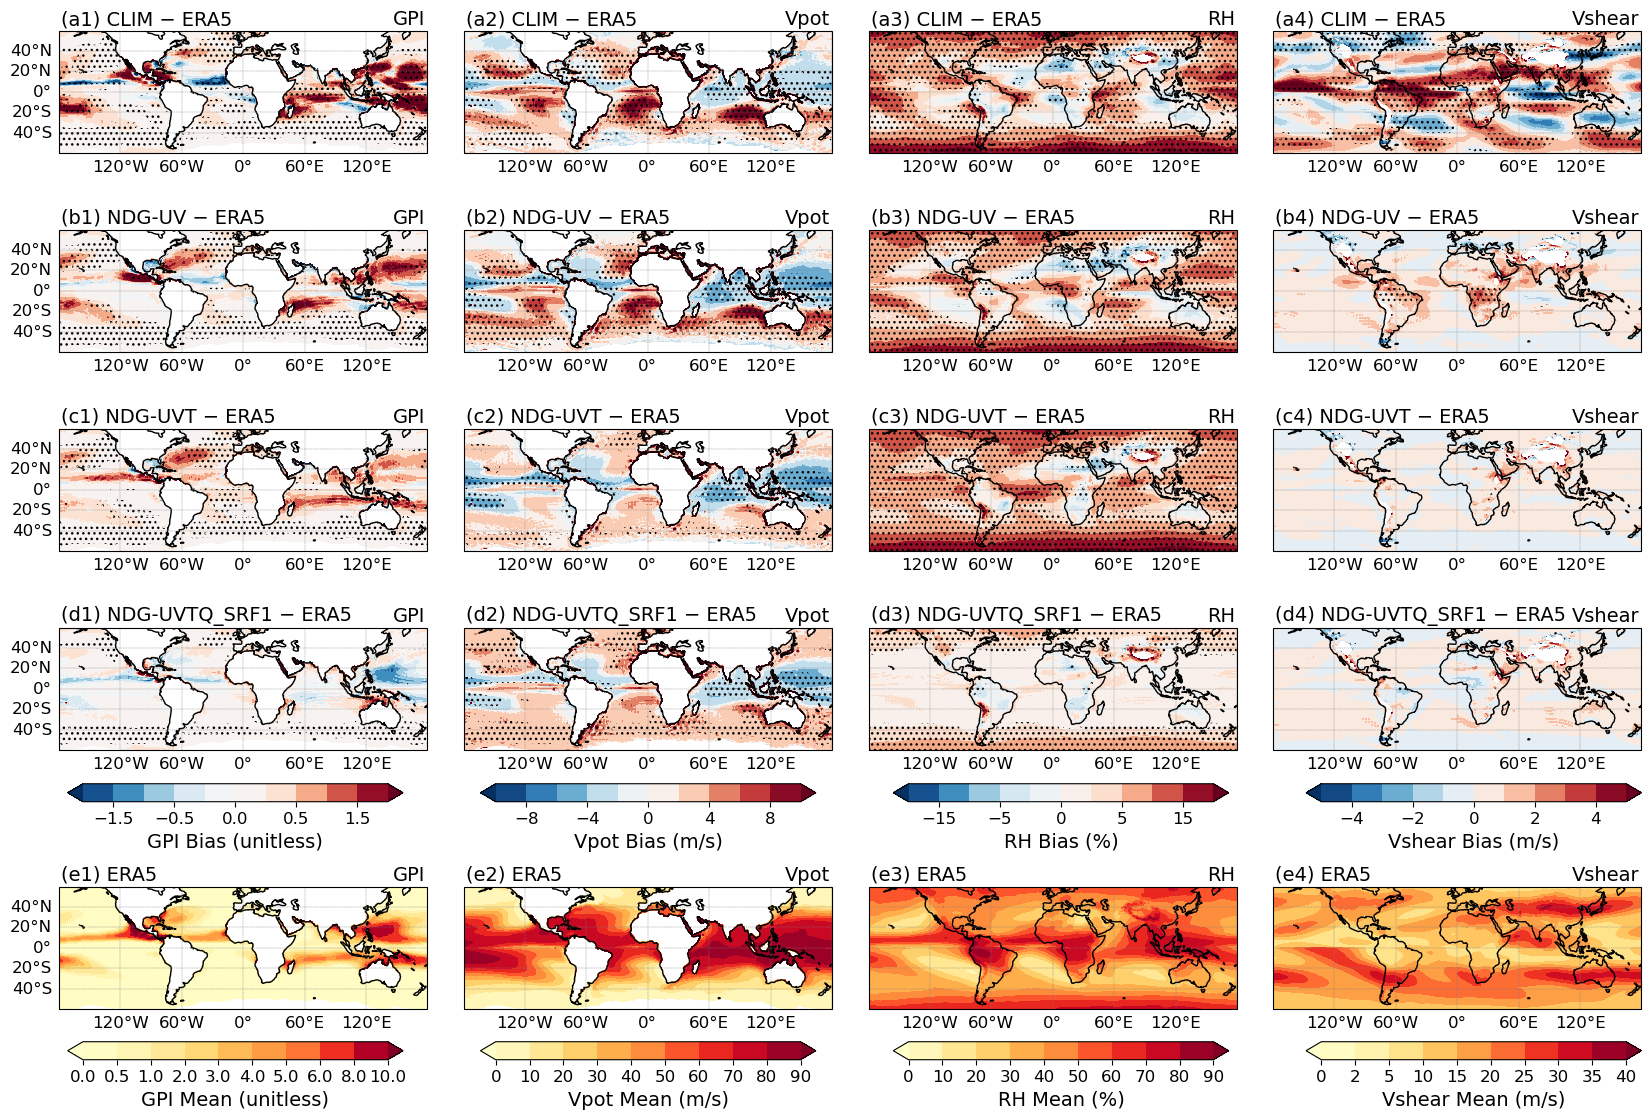

In [11]:
if __name__ == "__main__":
    # === Paths ===
    top_path = "/anvil/scratch/x-szhang3"
    data_path = f"{top_path}/post_data/TempestExtremes/TCS/GPI/output"
    ibtracs_path = f"{top_path}/post_data/TempestExtremes/TCS/OBS/tc_track/IBTrACS/IBTrACS.ALL.v04r00.nc"
    out_path = "/home/x-szhang3/nudging_analysis/nudging_evaluation/data/TempestExtremes/IBTrACS" 
    fig_path = "./"
    os.makedirs(out_path, exist_ok=True)

    # === Time Range ===
    syear, eyear = 2008, 2017
    monthly_genesis_path = os.path.join(out_path, f"IBTrACS_genesis_monthly_1deg_{syear}-{eyear}.nc")

    # === Experiments ===
    exp_dict = {
        "ERA5": "ERA5",
        "CLIM": "CLIM",
        "NDGUV": "NDG-UV",
        "NDGUVT": "NDG-UVT",
        "NDGUVTQ_SRF1": "NDG-UVTQ_SRF1"
    }

    # === Load or create IBTrACS genesis
    if os.path.exists(monthly_genesis_path):
        genesis_da = xr.open_dataset(monthly_genesis_path)["genesis_density"]
    else:
        analyzer = IBTrACSAnalyzer(ibtracs_path=ibtracs_path, syear=syear, eyear=eyear)
        analyzer.load_and_filter_ibtracs()
        analyzer.save_monthly_genesis_climatology(out_path=monthly_genesis_path, bins=(1.0, 1.0))
        genesis_da = xr.open_dataset(monthly_genesis_path)["genesis_density"]

    # === Load GPI diagnostics
    evaluator = GPIMetricEvaluator(
        data_dir=data_path,
        exp_dict=exp_dict,
        syear=syear,
        eyear=eyear,
        varname="GPI",
        ref_label="ERA5"
    )

    gpi_components = {
        "GPI":     {"alias": "GPI",     "unit": "unitless",
                    "clevels_mean": [0,0.5,1,2,3,4,5,6,8,10], #np.linspace(0, 10, 11),   
                    "clevels_bias": [-2,-1.5,-1,-0.5,-0.1,0,0.1,0.5,1,1.5,2]}, #np.linspace(-2, 2, 11)},
        "vmax":    {"alias": "Vpot",    "unit": "m/s",    
                    "clevels_mean": [0,10,20,30,40,50,60,70,80,90], #np.linspace(0, 100, 11), 
                    "clevels_bias": [-10,-8,-6,-4,-1,0,1,4,6,8,10]}, #np.linspace(-10, 10, 11)},
        "rh600":   {"alias": "RH",      "unit": "%",       
                    "clevels_mean": [0,10,20,30,40,50,60,70, 80,90], #np.linspace(30, 90, 13), 
                    "clevels_bias": [-20,-15,-10,-5,-2,0,2,5,10,15,20]}, #np.linspace(-25, 25, 11)},
        "Vshear":  {"alias": "Vshear",  "unit": "m/s",    
                    "clevels_mean": [0,2,5,10,15,20,25,30,35,40], #np.linspace(0, 40, 11),  
                    "clevels_bias": [-5,-4,-3,-2,-1,0,1,2,3,4,5]}, #np.linspace(-5, 5, 11)},
    }

    fig_name = "Figure_08.pdf"
    if fig_name is not None:
        output_file = os.path.join(fig_path,fig_name)
    else:
        output_file = os.path.join(fig_path,"Figure_combined_biases_and_ERA5_means.pdf")
        
    evaluator.plot_gpi_component_biases_and_means(
        genesis_da=genesis_da,
        gpi_components=gpi_components,
        output_path=output_file,
        fontz=14
    )
    